In [2]:
from langgraph.graph import START,END,StateGraph

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [8]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

In [9]:
arxiv.invoke("Attention is all you need!")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [10]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

In [12]:
wiki.invoke("what is langchain?")

'Page: Model Context Protocol\nSummary: The Model Context Protocol (MCP) is an open standard and open-source framework introduced by Anthropic in November 2024 to standardize the way artificial intelligence (AI) systems like large language models (LLMs) integrate and share data with external tools, systems, and data sources. MCP provides a universal interface for reading files, executing functions, and handling contextual prompts. Following its announcement, the protocol was adopted by major AI pr'

In [13]:
import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [14]:
from langchain_community.tools import TavilySearchResults

tavily=TavilySearchResults()

C:\Users\SAYANSH\AppData\Local\Temp\ipykernel_6668\1671565585.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


In [16]:
tavily.invoke("what is the current AI news for march 26 , 2026")

[{'title': 'AI Insights: Key Global Developments in March 2026',
  'url': 'https://www.riskinfo.ai/post/ai-insights-key-global-developments-in-march-2026',
  'content': 'Welcome to the March 2026 edition of our global AI update. The period from late February into mid-March saw AI moving from theory into practice.',
  'score': 0.98581},
 {'title': 'Morgan Stanley warns an AI breakthrough Is coming in 2026 - Fortune',
  'url': 'https://fortune.com/2026/03/13/elon-musk-morgan-stanley-ai-leap-2026/',
  'content': "A massive AI breakthrough is coming in the first half of 2026—and Morgan Stanley says most of the world isn't ready for it.",
  'score': 0.98579},
 {'title': "The New News in AI: 3/20/26 Edition - Mimir's Well",
  'url': 'https://markmcneilly.substack.com/p/the-new-news-in-ai-32026-edition',
  'content': "OpenAI is projected to burn $14 billion in 2026, up from $8 to $9 billion in 2025. Anthropic's margins have swung from -94% in 2024 to about +40",
  'score': 0.98445},
 {'title'

In [17]:
tools=[arxiv,wiki,tavily]

In [18]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-3.5-turbo")

In [19]:
llm_with_tools=llm.bind_tools(tools)

In [21]:
from langchain.messages import HumanMessage,AIMessage
from pprint import pprint

In [22]:
llm_with_tools.invoke([HumanMessage(content=f"what is the recent AI news")])

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 222, 'total_tokens': 242, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DNjOFjeHvo0UX3wU6IbGOFNELRe8L', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d2b53-9c47-74f2-9cd1-26feadf21960-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'call_T8L58RnYct34SlSjFLyGVMIC', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 222, 'output_tokens': 20, 'total_tokens': 242, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [23]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image,display

In [25]:
from typing_extensions import TypedDict
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]


In [26]:
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [30]:
graph=StateGraph(State)

graph.add_node("3tool_llm",tool_calling_llm)
graph.add_node("tools",ToolNode(tools=tools))

graph.add_edge(START,"3tool_llm")
graph.add_conditional_edges("3tool_llm",tools_condition)

graph.add_edge("3tool_llm",END)

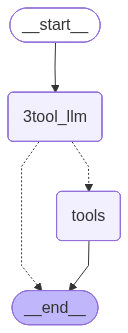

In [31]:
builder=graph.compile()

display(Image(builder.get_graph().draw_mermaid_png()))

In [35]:
builder.invoke({"messages":[HumanMessage(content="what is attention all you need")]})

{'messages': [HumanMessage(content='what is attention all you need', additional_kwargs={}, response_metadata={}, id='7982ff48-9357-4837-a03b-b6c185c85c44'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 222, 'total_tokens': 238, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DNjb9IQeV3cVisQ8tknamtxv5r5FX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d2b5f-d5dd-7fc1-aa72-b7cfbae076ec-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'attention all you need'}, 'id': 'call_MNV4YmkJLckRW0MZPVhY8btD', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 222, 'o